# Cohort Investigation

## Population characterization roadmap (TRIPOD-AI coverage)

This notebook builds the population-description pieces the TRIPOD-AI reporting checklist asks for. 

| TRIPOD-AI item | What the guideline is asking for | What this notebook builds for it | Status |
| --- | --- | --- | --- |
| **20a** | How many patients you started with and how many survived each filter, plus a follow-up summary | The attrition table: patient count dropped at every stage | Done |
| **5b** | The calendar span of the data — when the first and last patients entered, and how long they're watched afterward | A block printing earliest/latest anchor date and the spread of follow-up days | Done |
| **8a** | What "TRD" means as an outcome, how far ahead you look to call it, and whether it's measured the same way for everyone | The follow-up-time distribution (same block as 5b) | Done |
| **20b** | A summary describing the patients — age, sex, race, diagnoses, treatments, how many became TRD — overall and split TRD vs non-TRD | "Table 1": one row per characteristic, columns for everyone / TRD / non-TRD, plus a column showing how different the two groups are | Next |
| **3c** | Whether known health gaps show up between demographic groups | TRD rate broken out by sex, race, language, age band, and SDOH indicators | Open |
| **14** | Whether the model could even be evaluated fairly | The same breakdown, flagging any group with fewer than 20 patients (too small to trust) | Open |
| **7** | Whether data cleaning and missing values hit some demographic groups worse than others | For each column still missing data, the missing rate per demographic group | Partial (vitals check below) |
| **20c** | Proof the training and test patients look alike, not just share the same TRD rate | A table comparing every feature's distribution across train vs test | Open |
| **21** | How many patients and how many TRD cases sit in each split | Plain counts: patients and TRD-positives in train vs test | Open |
| **10** | Whether there are enough TRD cases for the number of features to trust the model | TRD count divided by feature count, checked against the >= 10 rule of thumb | Open |

Item **5a** (data sources and representativeness) and the model-side items (12, 13, 15, 22, 23, 24) are deferred to manuscript prose / the classical-ML and ablation pipelines — not this notebook.


### Make the root project directory the access point for 'os'

In [2]:
import sys
from pathlib import Path
import os
sys.path.append(str(Path(os.getcwd()).parent))
Path(os.getcwd())

PosixPath('/mnt/dell_storage/homefolders/librad.laureateinstitute.org/mferguson/Digital-Twins/notebooks')

## TRIPOD-AI 20a · Participant flow — total valid population

In [2]:
from pathlib import Path

print(len(list(Path('/media/studies/ehr_study/analysis/mferguson/sliced_patient_json/').glob("*.json"))))

9725


## TRIPOD-AI 20a · Participant flow — TRD outcome counts

Positive vs negative TRD labels across the valid cohort.

In [3]:
from pathlib import Path
import os

from dotenv import load_dotenv
load_dotenv('../.env')

from scripts.digital_twins.predictions.trd_predictor import TRDPredictor

predictor = TRDPredictor()

positive_count = 0
negative_count = 0
for p in Path(os.environ['SLICED_PATIENT_JSON_DIR']).glob("*.json"):
    pid = p.stem
    positive_count += predictor.get_trd_status(pid)
    negative_count += 1 - predictor.get_trd_status(pid)

print(f"Positive count: {positive_count}\nNegative count: {negative_count}")

Positive count: 1034
Negative count: 8691


## TRIPOD-AI 20a · Participant flow — cohort attrition

Rejection-reason tally plus the full stage-by-stage attrition table (raw population down to the final analysis set), saved to `figures/attrition_table.csv`. This is the completed 20a deliverable that underwrites every denominator in the roadmap above.

In [4]:
from pathlib import Path
import os

from dotenv import load_dotenv
load_dotenv()

sliced_json_dir = Path(os.environ['SLICED_PATIENT_JSON_DIR'])
total = len(list(sliced_json_dir.glob("*")))
rejected = list(sliced_json_dir.glob("*.rejected"))
print([p.stem for p in rejected[:5]])
print(f"{len(rejected)} total rejections out of {total} patients")

['CB1D2CE25E7616D883D57748086D0C85', '04F701D8459A5CBDCB925237D1CE423D', '0920D0D00C1EFEF4584C1D1FB20D8DD3', '8F35ACD5B20D5635EB0227C46E3BC788', '9B3D401163209B8EC42B4C22C5E06CB1']
33605 total rejections out of 43330 patients


In [5]:
from collections import Counter
import json
import os

from dotenv import load_dotenv
load_dotenv()

sliced_json_dir = Path(os.environ['SLICED_PATIENT_JSON_DIR'])
counter = Counter([json.loads(p.read_text())['reason'] for p in (sliced_json_dir.glob("*.rejected"))])
print(json.dumps(counter, indent=4))

{
    "Insufficient post-anchor history (require 1 years)": 7074,
    "Insufficient pre-anchor history (require 2 years)": 26342,
    "No MDD diagnosis before anchor": 189
}


In [ ]:
import os
import pandas as pd
import sys
from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent))

from dotenv import load_dotenv
load_dotenv()

from scripts.data_loading.create_cohort import extract_ids
from scripts.data_loading.fit_to_anchor import NO_MDD, PRE_ANCHOR, POST_ANCHOR

person_df = pd.read_csv(Path(os.environ['PERSON_CSV_PATH']))
n = len(person_df)

prep_data_dir = Path(os.environ['PREP_DATA_DIR'])
mdd, bd, sch = extract_ids(prep_data_dir / "MDD_IDs.csv"), extract_ids(prep_data_dir / "BD_IDs.csv"), extract_ids(prep_data_dir / "SCH_IDs.csv")
valid = mdd - (bd | sch)

# Make sure the cohort path contains a .csv with the same patient count
cohort_df = pd.read_csv(Path(os.environ['COHORT_PATH']))
assert len(cohort_df) == len(valid), f"Mismatching lengths of {len(cohort_df)} and {len(valid)}"

mdd_med_date_df = pd.read_csv(Path(os.environ['MDD_MED_DATE_CSV_PATH']), escapechar='\\', low_memory=False)
mdd_med_date_df.set_index('PatientEpicId_SH', inplace=True)
mdd_med_date_df = mdd_med_date_df.loc[mdd_med_date_df.index.isin(valid)]
mdd_med_date_df.sort_values(by='MedStartInstant', inplace=True)
mdd_med_date_df = mdd_med_date_df[~mdd_med_date_df.index.duplicated(keep='first')] # Don't include anything that is a later duplicate

n_has_anchor = len(mdd_med_date_df)
print(f"Number of patients with anchor: {n_has_anchor}")

stages = ["Raw population", "MDD-diagnosed", "Not BD AND not SCH", "Has antidepressant anchor", "Has MDD before anchor", f"Has at least {int(os.environ['YEARS_BACK'])} year(s) of pre-anchor history", f"Has at least {int(os.environ['YEARS_AHEAD'])} year(s) of post-anchor follow-up"]
n_remaining = [n, len(mdd), len(cohort_df), n_has_anchor, n_has_anchor - counter[NO_MDD], n_has_anchor - counter[NO_MDD] - counter[PRE_ANCHOR], n_has_anchor - counter[NO_MDD] - counter[PRE_ANCHOR] - counter[POST_ANCHOR]]
n_rejected = [n_remaining[i-1] - n_remaining[i] if i > 0 else 0 for i in range(len(n_remaining))]
population_filter_df = pd.DataFrame({
    "stage": stages,
    "n_remaining": n_remaining,
    "n_rejected_at_stage": n_rejected
})
save_folder = Path("notebooks/figures")
save_folder.mkdir(parents=True, exist_ok=True)
population_filter_df.to_csv(save_folder / "attrition_table.csv", index=False)
population_filter_df

Number of patients with anchor: 43330


,stage,n_remaining,n_rejected_at_stage
0,Raw population,502118,0
1,MDD-diagnosed,73942,428176
2,Not BD AND not SCH,61806,12136
3,Has antidepressant anchor,43330,18476
4,Has MDD before anchor,43141,189
5,Has at least 2 year(s) of pre-anchor history,16799,26342
6,Has at least 1 year(s) of post-anchor follow-up,9725,7074


## TRIPOD-AI 7 & 11 · Data quality and missing data — vitals missingness diagnostic

Three-tier check (in-window only / all pre-anchor history / any date at all) of how often the vital signs are missing, and whether that missingness differs between TRD and non-TRD patients.

In [ ]:
import os
from pathlib import Path
import pandas as pd
import json
import sys
sys.path.append(str(Path(os.getcwd()).parent))

from scripts.digital_twins.predictions.trd_predictor import TRDPredictor

from dotenv import load_dotenv
load_dotenv()

vital_keys = [
    "SystolicBloodPressure", 
    "DiastolicBloodPressure", 
    "PulseRate", 
    "RespirationRate",
    "WeightInGrams", 
    "HeightInInches", 
    "TemperatureInFahrenheit", 
    "BodyMassIndex"
]

predictor = TRDPredictor()
patient_infos = []
for p in Path(os.environ['SLICED_PATIENT_JSON_DIR']).glob("*.json"):
    with open(p, 'r') as f:
        vitals_to_check_for_patient = set(vital_keys)
        patient_json = json.load(f)
        patient_info = {
            "patient_id": patient_json['patient_id'],
            "mdd_to_anchor_days": patient_json['mdd_to_anchor_days'],
            'num_encounters': len(patient_json['encounters']),
            'pre_anchor_history_days': patient_json['pre_anchor_history_days'],
            'trd_label': predictor.get_trd_status(patient_json['patient_id'])
        }
        
        # Now go through each encounter and see if any of the vital keys are matched - remove any that are so we do not recheck
        for encounter in patient_json['encounters']:
            for vital in encounter['vitals']:
                for vital_key in list(vitals_to_check_for_patient):
                    temp = vital.get(vital_key)
                    if (isinstance(temp, float) or isinstance(temp, int)) and temp > 0:
                        vitals_to_check_for_patient.discard(vital_key)
        
        for key in vital_keys:
            patient_info[f"missing_{key}"] = key in vitals_to_check_for_patient
        patient_infos.append(patient_info)
                
df = pd.DataFrame(patient_infos)
df.head()

,patient_id,mdd_to_anchor_days,num_encounters,pre_anchor_history_days,trd_label,missing_SystolicBloodPressure,missing_DiastolicBloodPressure,missing_PulseRate,missing_RespirationRate,missing_WeightInGrams,missing_HeightInInches,missing_TemperatureInFahrenheit,missing_BodyMassIndex
0,859583BC32EBEE0476C127679677A7D2,0,10,1330,0,True,True,True,True,True,True,True,True
1,B31487E3C6C47AEFFD079148B89DFF7C,59,18,1091,0,False,False,False,True,False,False,False,False
2,9EF10EFC520C572E223D69866E5AEAAE,631,13,848,1,False,False,False,True,False,False,False,False
3,EC996742DEFB3C68648CB3D09B6B9072,103,8,1423,0,True,True,True,True,True,True,True,True
4,E98075DF8BBEBC0E93B6EDE1185FE809,1,7,2504,0,True,True,True,True,False,False,True,False


In [8]:
missing_percentage_df = (df.filter(like='missing_').mean() * 100).sort_values(ascending=False)
missing_percentage_df # Most missing vitals first, in descending order

missing_RespirationRate            79.516710
missing_TemperatureInFahrenheit    71.753213
missing_PulseRate                  69.984576
missing_DiastolicBloodPressure     69.244216
missing_SystolicBloodPressure      69.244216
missing_HeightInInches             64.503856
missing_BodyMassIndex              63.506427
missing_WeightInGrams              63.485861
dtype: float64

In [9]:
filtered_present_at_all = df.filter(regex='^(trd_label|missing_)') # Grab label and the missing vitals labels (9 columns)
# For each label, see the difference in proportions of TRD positive vs TRD negative patients who are missing
missing_difference_present_at_all = filtered_present_at_all.groupby('trd_label').mean()\
    .mul(100)\
        .T\
            .rename(columns={0: 'trd_neg_pct', 1: 'trd_pos_pct'})\
                .assign(delta_pct=lambda x: x['trd_pos_pct'] - x['trd_neg_pct'])\
                    .sort_values('delta_pct', key=abs, ascending=False)\
                        .rename_axis(None, axis=1)
# Positive means more TRD are missing, negative means more non TRD are missing
missing_difference_present_at_all

,trd_neg_pct,trd_pos_pct,delta_pct
missing_WeightInGrams,62.432401,72.340426,9.908024
missing_BodyMassIndex,62.455414,72.340426,9.885012
missing_HeightInInches,63.467955,73.210832,9.742876
missing_SystolicBloodPressure,68.335059,76.885880,8.550821
missing_DiastolicBloodPressure,68.335059,76.885880,8.550821
missing_PulseRate,69.117478,77.272727,8.155249
missing_TemperatureInFahrenheit,71.073524,77.466151,6.392627
missing_RespirationRate,78.840179,85.203095,6.362915


In [10]:
df_three = df[["missing_BodyMassIndex", "missing_SystolicBloodPressure", "missing_DiastolicBloodPressure", "trd_label"]].copy()
df_three['n_missing_vitals'] = df_three[["missing_BodyMassIndex", "missing_SystolicBloodPressure", "missing_DiastolicBloodPressure"]].sum(axis=1)
# What percentages of patients are missing 0, 1, 2, or 3 vitals
marginal_pct = df_three['n_missing_vitals'].value_counts()\
    .sort_index()\
        .div(len(df_three))\
            .mul(100)
marginal_pct

n_missing_vitals
0    30.231362
1     0.524422
2     6.262211
3    62.982005
Name: count, dtype: float64

In [11]:
# When we are missing vitals, how likely are we to be missing all 3?
at_least_one = df_three[df_three['n_missing_vitals'] >= 1]
p_all_three = (at_least_one['n_missing_vitals'] == 3).mean() * 100
p_two = (at_least_one['n_missing_vitals'] == 2).mean() * 100
p_one = (at_least_one['n_missing_vitals'] == 1).mean() * 100

print(f"All three: {p_all_three}\nTwo: {p_two}\nOne: {p_one}")

All three: 90.27266028002948
Two: 8.975681650700073
One: 0.7516580692704495


In [12]:
# Is the pattern of missingness the same between TRD/non-TRD
by_trd_group = df_three.groupby('trd_label')['n_missing_vitals']\
    .value_counts(normalize=True)\
        .mul(100)\
            .unstack(level='n_missing_vitals')\
                .rename_axis(None, axis=1)
by_trd_group

,0,1,2,3
trd_label,,,,
0,31.147164,0.517777,6.397423,61.937637
1,22.533849,0.580271,5.125725,71.760155


In [13]:
import pandas as pd
import os
from pathlib import Path

vitals_csv_path = Path(os.environ['VITALS_CSV_PATH'])
vitals_df_raw = pd.read_csv(vitals_csv_path, escapechar='\\', low_memory=False)
# For each patient, how many vitals to they have?
vital_rows_per_patient = vitals_df_raw.groupby('PatientEpicId_SH').size()
print(f"Unique patients with at least one vital row: {len(vital_rows_per_patient)}...")

Unique patients with at least one vital row: 110061...


In [14]:
cohort_vital_row_count = vital_rows_per_patient.reindex(df['patient_id'], fill_value=0)
df['n_vital_rows_in_source'] = cohort_vital_row_count.values
print(f"Vital row count per cohort patient:\n{df['n_vital_rows_in_source'].describe()}")

Vital row count per cohort patient:
count    9725.000000
mean        3.831979
std         5.461501
min         0.000000
25%         0.000000
50%         2.000000
75%         5.000000
max        78.000000
Name: n_vital_rows_in_source, dtype: float64


In [15]:
pct_cohort_with_zero_vital_rows = (df['n_vital_rows_in_source'] == 0).mean() * 100
print(f"% of cohort with ZERO vital rows in source (any date): {pct_cohort_with_zero_vital_rows}%")
missing_bmi_subset = df[df['missing_BodyMassIndex'] == True]
pct_flagged_missing_who_had_rows_out_of_window = (missing_bmi_subset['n_vital_rows_in_source'] > 0).mean() * 100
print(f"of patients flagged missing_bodyMassIndex, {pct_flagged_missing_who_had_rows_out_of_window}% had vital rows in source but outside YEARS_BACK window")

% of cohort with ZERO vital rows in source (any date): 28.380462724935736%
of patients flagged missing_bodyMassIndex, 55.31088082901554% had vital rows in source but outside YEARS_BACK window


In [16]:
# Investigate if vital readings occurred before the 2 year pre-AD anchor cutoff
anchor_csv_path = Path(os.environ['MDD_MED_DATE_CSV_PATH'])
anchor_df_raw = pd.read_csv(anchor_csv_path, escapechar='\\', low_memory=False)
print(anchor_df_raw.columns.tolist())
print(anchor_df_raw.dtypes)

['MedicationEventKey', 'PatientEpicId_SH', 'MedOrderNumber', 'MedCode', 'MedicationEpicID', 'MedName', 'MedGenericName', 'MedSimpleGenericName', 'MedTherapeuticClass', 'MedPharmaceuticalClass', 'MedPharmaceuticalSubclass', 'MedDeaClass', 'MedStrength', 'MedForm', 'MedRoute', 'MedDoseUnit', 'ControlledMed_YN', 'OpioidMed_YN', 'MedStartInstant', 'MedEndInstant', 'MedAdministrationInstant', 'MedOrderedInstant', 'MedPatientMode', 'MedOrderType', 'MedFrequency', 'RefillsWritten', 'DaysSupply', 'DiscontinueReason', 'DiscontinuedDate', 'GroupType', 'first_depression_dx_date', 'n_drugs_prescribed', 'n_unique_drugs_prescribed']
MedicationEventKey             int64
PatientEpicId_SH              object
MedOrderNumber                 int64
MedCode                        int64
MedicationEpicID               int64
MedName                       object
MedGenericName                object
MedSimpleGenericName          object
MedTherapeuticClass           object
MedPharmaceuticalClass        object
Med

In [17]:
anchor_indexed = anchor_df_raw.set_index('PatientEpicId_SH')
anchor_indexed = anchor_indexed.sort_values(by='MedStartInstant', ascending=True)
earliest_mask = ~anchor_indexed.index.duplicated(keep='first')
anchor_indexed = anchor_indexed[earliest_mask]
anchor_indexed['anchor_date'] = pd.to_datetime(anchor_indexed['MedStartInstant'], format='%Y-%m-%d')
print(f"Unique cohort-candidate patients with an anchor: {len(anchor_indexed)}")

Unique cohort-candidate patients with an anchor: 53418


In [18]:
anchor_lookup = anchor_indexed['anchor_date']
vitals_df_raw['vital_date'] = pd.to_datetime(vitals_df_raw['StartVisit'], format='%Y-%m-%d', errors='coerce')
vitals_df_raw['anchor_date'] = vitals_df_raw['PatientEpicId_SH'].map(anchor_lookup)
print(f"Malformed Dates: {vitals_df_raw['vital_date'].isna().sum()}")
print(f"Vitals belonging to non-anchor or non-cohort patients: {vitals_df_raw['anchor_date'].isna().sum()}")

Malformed Dates: 0
Vitals belonging to non-anchor or non-cohort patients: 240075


In [19]:
YEARS_BACK = int(os.environ['YEARS_BACK'])
vitals_joined = vitals_df_raw[vitals_df_raw['anchor_date'].notna()]
vitals_joined['cutoff_date'] = vitals_joined['anchor_date'] - pd.Timedelta(days=YEARS_BACK*365)
pre_window_mask = vitals_joined['vital_date'] < vitals_joined['cutoff_date']
in_window_mask = (vitals_joined['vital_date'] >= vitals_joined['cutoff_date']) & (vitals_joined['vital_date'] <= vitals_joined['anchor_date'])
post_window_mask = vitals_joined['vital_date'] > vitals_joined['anchor_date']
print(f"Pre-window: {pre_window_mask.sum()}")
print(f"In-window: {in_window_mask.sum()}")
print(f"Post-window: {post_window_mask.sum()}")

Pre-window: 14756
In-window: 23702
Post-window: 63358


/tmp/ipykernel_2584659/3860371407.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vitals_joined['cutoff_date'] = vitals_joined['anchor_date'] - pd.Timedelta(days=YEARS_BACK*365)


In [20]:
pre_window_rows = vitals_joined[pre_window_mask]
patients_with_pre_window_vital = set(pre_window_rows['PatientEpicId_SH'].unique())
df['has_pre_window_vital'] = df['patient_id'].isin(patients_with_pre_window_vital)
missing_bmi_subset_v2 = df[df['missing_BodyMassIndex'] == True]
pct_flagged_missing_with_pre_window_vital = (missing_bmi_subset_v2['has_pre_window_vital']).mean()*100
print(f"% of Patients flagged as missing bmi with pre-window bmi: {pct_flagged_missing_with_pre_window_vital}")

% of Patients flagged as missing bmi with pre-window bmi: 23.898963730569946


In [21]:
# If we have unlimited time before the anchor, what percentage of patients will be missing each vital?
present_at_all_mask = pre_window_mask | in_window_mask
present_at_all_rows = vitals_joined[present_at_all_mask]
for key in vital_keys:
    patients_with_key = set(present_at_all_rows[present_at_all_rows[key] > 0]['PatientEpicId_SH'].unique())
    df[f'missing_{key}_extended'] = ~df['patient_id'].isin(patients_with_key)

filtered_present_at_all = df.filter(regex='^(trd_label|missing_.*_extended)') # Grab label and the missing vitals labels (9 columns)
# For each label, see the difference in proportions of TRD positive vs TRD negative patients who are missing
missing_difference_present_at_all = filtered_present_at_all.groupby('trd_label').mean()\
    .mul(100)\
        .T\
            .rename(columns={0: 'trd_neg_pct', 1: 'trd_pos_pct'})\
                .assign(delta_pct=lambda x: x['trd_pos_pct'] - x['trd_neg_pct'])\
                    .sort_values('delta_pct', key=abs, ascending=False)\
                        .rename_axis(None, axis=1)
# Positive means more TRD are missing, negative means more non TRD are missing
missing_difference_present_at_all

,trd_neg_pct,trd_pos_pct,delta_pct
missing_WeightInGrams_extended,47.382350,58.317215,10.934865
missing_BodyMassIndex_extended,47.600967,58.413926,10.812960
missing_HeightInInches_extended,48.498447,59.187621,10.689174
missing_SystolicBloodPressure_extended,53.503624,62.959381,9.455757
missing_DiastolicBloodPressure_extended,53.503624,62.959381,9.455757
missing_PulseRate_extended,53.906340,63.152805,9.246465
missing_TemperatureInFahrenheit_extended,57.082039,65.280464,8.198425
missing_RespirationRate_extended,68.726269,75.241779,6.515511


In [22]:
# No limits on when the vital occurs
present_at_all_mask = pre_window_mask | in_window_mask | post_window_mask
present_at_all_rows = vitals_joined[present_at_all_mask]
for key in vital_keys:
    patients_with_key = set(present_at_all_rows[present_at_all_rows[key] > 0]['PatientEpicId_SH'].unique())
    df[f'missing_{key}_present_at_all'] = ~df['patient_id'].isin(patients_with_key)

filtered_present_at_all = df.filter(regex='^(trd_label|missing_.*_present_at_all)') # Grab label and the missing vitals labels (9 columns)
# For each label, see the difference in proportions of TRD positive vs TRD negative patients who are missing
missing_difference_present_at_all = filtered_present_at_all.groupby('trd_label').mean()\
    .mul(100)\
        .T\
            .rename(columns={0: 'trd_neg_pct', 1: 'trd_pos_pct'})\
                .assign(delta_pct=lambda x: x['trd_pos_pct'] - x['trd_neg_pct'])\
                    .sort_values('delta_pct', key=abs, ascending=False)\
                        .rename_axis(None, axis=1)
# Positive means more TRD are missing, negative means more non TRD are missing
missing_difference_present_at_all

,trd_neg_pct,trd_pos_pct,delta_pct
missing_HeightInInches_present_at_all,29.789437,38.588008,8.798570
missing_BodyMassIndex_present_at_all,28.719365,37.330754,8.611389
missing_WeightInGrams_present_at_all,28.650328,37.234043,8.583715
missing_SystolicBloodPressure_present_at_all,34.288344,41.586074,7.297729
missing_DiastolicBloodPressure_present_at_all,34.288344,41.586074,7.297729
missing_PulseRate_present_at_all,35.473478,42.069632,6.596154
missing_TemperatureInFahrenheit_present_at_all,39.247497,44.584139,5.336642
missing_RespirationRate_present_at_all,48.268324,52.514507,4.246183


## TRIPOD-AI 5b & 8a

Range of the anchor dates and distribution of post-anchor history length

Earliest Anchor Date: 2016-07-06 00:00:00
Latest Anchor Date: 2024-09-03 00:00:00
Difference in days: 2981



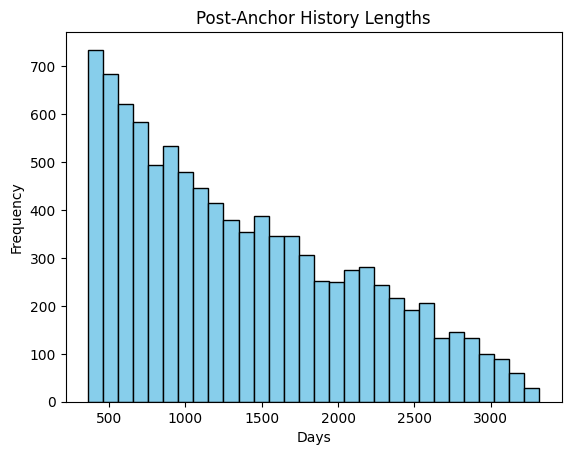

In [23]:
from datetime import datetime
import os
from pathlib import Path
import json
import matplotlib.pyplot as plt

from dotenv import load_dotenv
load_dotenv()

sliced_json_dir = Path(os.environ['SLICED_PATIENT_JSON_DIR'])

# Find earliest and latest anchor dates and the difference between them
earliest = None
latest = None
pop_ids = []
anchor_dates = {}
for p in sliced_json_dir.glob("*.json"):
    pop_ids.append(p.stem)
    with open(p, 'r') as f:
        sliced_json = json.load(f)
        anchor = datetime.strptime(sliced_json['anchor_date'], "%Y-%m-%d")
        if earliest == None:
            earliest = anchor
        else:
            earliest = min(earliest, anchor)
            
        if latest == None:
            latest = anchor
        else:
            latest = max(latest, anchor)
            
        # Record the anchor
        anchor_dates[p.stem] = anchor
difference = (latest - earliest).days
print(f"Earliest Anchor Date: {earliest}")
print(f"Latest Anchor Date: {latest}")
print(f"Difference in days: {difference}\n")

# Now for all patients, find the date of the latest encounter and see how much later it occurs than the anchor date
raw_json_path = Path(os.environ['PATIENT_JSON_DIR'])
post_anchor_history_lengths = []
for id in pop_ids:
    patient_raw_json_path = raw_json_path / f"{id}.json"
    with open(patient_raw_json_path, 'r') as f:
        raw_patient_json = json.load(f)
        latest_encounter_date = None
        for encounter in raw_patient_json['encounters']:
            start = datetime.strptime(encounter['details']['start_visit'], "%Y-%m-%d")
            if latest_encounter_date is None or start > latest_encounter_date:
                latest_encounter_date = start
        # Now find the difference between that and the anchor date
        post_anchor_history_lengths.append((latest_encounter_date - anchor_dates[id]).days)

# Create histogram
plt.hist(post_anchor_history_lengths, bins=30, color='skyblue', edgecolor='black')

# Add labels
plt.title('Post-Anchor History Lengths')
plt.xlabel('Days')
plt.ylabel('Frequency')

plt.show()

In [ ]:
import os
from pathlib import Path
import pandas as pd
import json

import sys
sys.path.append(str(Path(os.getcwd()).parent))

from scripts.digital_twins.predictions.trd_predictor import TRDPredictor
from scripts.shared.utils import VITAL_COLUMNS

predictor = TRDPredictor()

feature_vector_df = pd.read_parquet(Path(os.environ['FEATURE_DATAFRAME_PATH']))
# Indexed by patient id - use to get trd_status
feature_vector_df['trd_label'] = feature_vector_df.index.map(predictor.get_trd_status)

feature_vector_df = feature_vector_df.drop(columns=list(VITAL_COLUMNS))

# Split into different classes of attributes
floats_df = feature_vector_df.select_dtypes(include='float64')
categorical_df = feature_vector_df.select_dtypes(include='category')
bool_df = feature_vector_df.select_dtypes(include='bool')

# Obtain statistics for each population
QUANTILES = [0.25, 0.5, 0.75]
group_by_label = feature_vector_df.groupby('trd_label')

# Numeric
grouped_float_quantiles = group_by_label[floats_df.columns].quantile(QUANTILES)
overall_float_quantiles = floats_df.quantile(QUANTILES)

# Boolean
grouped_bool_proportions = group_by_label[bool_df.columns].mean()
grouped_bool_pos_count = group_by_label[bool_df.columns].sum()
overall_bool_proportions = bool_df.mean()
overall_bool_pos_count = bool_df.sum()

# Categorical
grouped_categorical_grid_proportions = {}
overall_categorical_grid_proportions = {}
for col in categorical_df.columns:
    # For each categorical variable, obtain the proportions each of the variable's values occurs
    overall_categorical_grid_proportions[col] = categorical_df[col].value_counts(normalize=True).to_dict()
    # For each column/categorical variable, make a grid with two columns - TRD/non-TRD, and the proportions of all the values each variable takes on in each subclass
    grouped_categorical_grid_proportions[col] = pd.crosstab(feature_vector_df[col], feature_vector_df['trd_label'], normalize='columns').to_dict()

save_folder = Path("notebooks/figures")
save_folder.mkdir(parents=True, exist_ok=True)

with open(save_folder / "grouped_categorical.json", 'w') as f:
    json.dump(grouped_categorical_grid_proportions, f, indent=4)
with open(save_folder / "overall_categorical.json", 'w') as f:
    json.dump(overall_categorical_grid_proportions, f, indent=4)

grouped_bool_pos_count.to_csv(save_folder / "grouped_bool_count.csv")
grouped_bool_proportions.to_csv(save_folder / "grouped_bool_proportions.csv")
overall_bool_pos_count.to_csv(save_folder / "overall_bool_count.csv")
overall_bool_proportions.to_csv(save_folder / "overall_bool_proportions.csv")

grouped_float_quantiles.to_csv(save_folder / "grouped_numeric.csv")
overall_float_quantiles.to_csv(save_folder / "overall_numeric.csv")